# Sales Performance Analysis

## Project Overview
This analysis explores **700 sales transactions** from a multinational company across **5 countries** (Germany, Canada, France, Mexico, USA), covering **6 products** and **5 customer segments** over **16 months** (September 2013 - December 2014).

## Objectives
We answer four key business questions:
1. **How much are we selling?** - Revenue breakdown by country, product, and segment
2. **Is performance improving or declining over time?** - Monthly trends and year-over-year comparison
3. **Which products drive results?** - Product-level revenue, profit, and margin analysis
4. **Are sales profitable?** - Profitability by segment, country, and discount band

## Dataset
- **Source:** `Sample_data.xlsx`
- **Rows:** 700 | **Columns:** 16
- **Key fields:** Segment, Country, Product, Discount Band, Units Sold, Gross Sales, Sales (Net), COGS, Profit, Date

---
## 1. Setup & Data Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load raw data
df_raw = pd.read_excel('Sample_data.xlsx')
print(f'Raw dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
df_raw.head()

Raw dataset: 700 rows, 16 columns


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [3]:
# Check missing values before cleaning
print('Missing values per column:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])

Missing values per column:
Discount Band    53
dtype: int64


In [4]:
# Clean the data using logic from Data_cleaning.py
df = df_raw.copy()

# Fix column name (leading space in ' Sales')
df = df.rename(columns={' Sales': 'Sales'})

# Fill missing Discount Band based on discount percentage
df['discount_pct'] = df['Discounts'] / df['Gross Sales']

def assign_disc_band(value):
    if value == 0:
        return 'None'
    elif value <= 0.04:
        return 'Low'
    elif value <= 0.09:
        return 'Medium'
    else:
        return 'High'

df['Discount Band'] = df['Discount Band'].fillna(df['discount_pct'].apply(assign_disc_band))
df = df.drop('discount_pct', axis=1)

# Drop redundant date columns (we keep 'Date')
df = df.drop(['Month Number', 'Month Name', 'Year'], axis=1)

# Strip whitespace from text columns
for col in ['Country', 'Segment', 'Product', 'Discount Band']:
    df[col] = df[col].str.strip()

print(f'Cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Missing values remaining: {df.isnull().sum().sum()}')
df.head()

Cleaned dataset: 700 rows, 13 columns
Missing values remaining: 0


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date
0,Government,Germany,Carretera,None,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01
1,Government,Germany,Paseo,None,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01
2,Government,Canada,Paseo,None,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01
3,Government,Germany,Paseo,None,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01
4,Government,Germany,Velo,None,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01


In [5]:
# Data consistency checks
sales_check = (df['Sales'] - (df['Gross Sales'] - df['Discounts'])).abs().max()
profit_check = (df['Profit'] - (df['Sales'] - df['COGS'])).abs().max()
print(f'Sales consistency (max error): ${sales_check:.2f}')
print(f'Profit consistency (max error): ${profit_check:.2f}')
print('Data is consistent (small rounding errors only).')

Sales consistency (max error): $0.00
Profit consistency (max error): $0.00
Data is consistent (small rounding errors only).


---
## 2. KPI Summary Dashboard

In [6]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_units = df['Units Sold'].sum()
total_cogs = df['COGS'].sum()
profit_margin = (total_profit / total_revenue) * 100
avg_profit_per_unit = total_profit / total_units

kpi_data = {
    'Metric': ['Total Revenue', 'Total Profit', 'Total COGS', 'Total Units Sold',
               'Profit Margin', 'Avg Profit per Unit'],
    'Value': [
        f'${total_revenue:,.0f}',
        f'${total_profit:,.0f}',
        f'${total_cogs:,.0f}',
        f'{total_units:,.0f}',
        f'{profit_margin:.1f}%',
        f'${avg_profit_per_unit:,.2f}'
    ]
}
pd.DataFrame(kpi_data).style.hide(axis='index').set_properties(**{'font-size': '14px'})

Metric,Value
Total Revenue,"$118,726,350"
Total Profit,"$16,893,702"
Total COGS,"$101,832,648"
Total Units Sold,"1,125,806"
Profit Margin,14.2%
Avg Profit per Unit,$15.01


---
## 3. How Much Are We Selling?
Revenue breakdown by country, product, and customer segment.

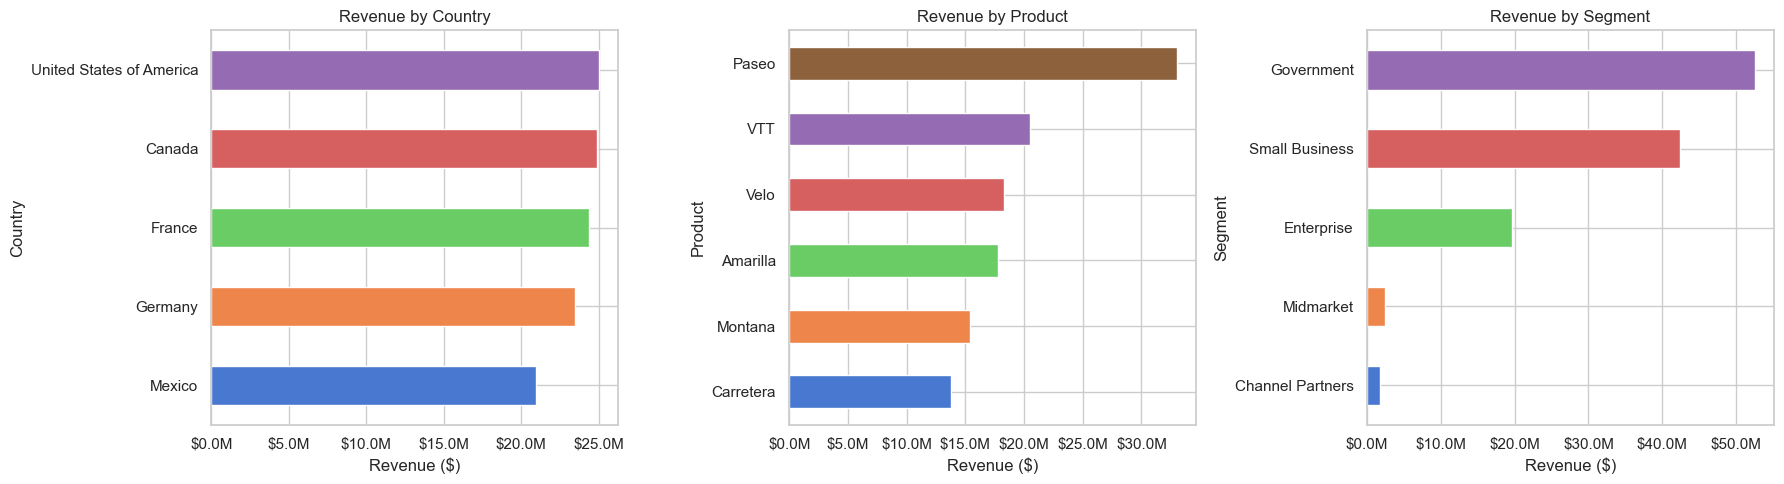

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue by Country
rev_country = df.groupby('Country')['Sales'].sum().sort_values()
rev_country.plot.barh(ax=axes[0], color=sns.color_palette('muted', len(rev_country)))
axes[0].set_title('Revenue by Country')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Revenue by Product
rev_product = df.groupby('Product')['Sales'].sum().sort_values()
rev_product.plot.barh(ax=axes[1], color=sns.color_palette('muted', len(rev_product)))
axes[1].set_title('Revenue by Product')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Revenue by Segment
rev_segment = df.groupby('Segment')['Sales'].sum().sort_values()
rev_segment.plot.barh(ax=axes[2], color=sns.color_palette('muted', len(rev_segment)))
axes[2].set_title('Revenue by Segment')
axes[2].set_xlabel('Revenue ($)')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

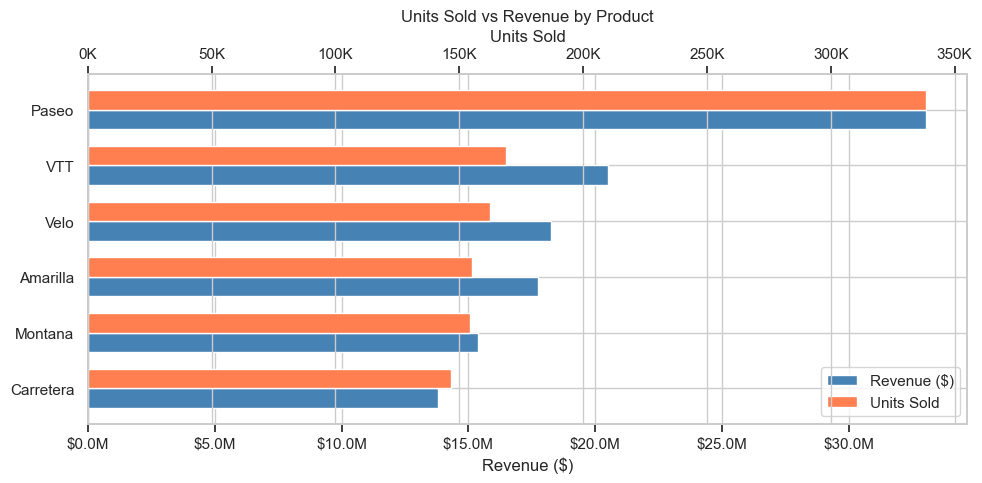

In [8]:
# Units Sold vs Revenue by Product
product_stats = df.groupby('Product').agg({'Units Sold': 'sum', 'Sales': 'sum'}).sort_values('Sales')

fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(product_stats))
width = 0.35

ax1.barh([i - width/2 for i in x], product_stats['Sales'], width, label='Revenue ($)', color='steelblue')
ax1.set_xlabel('Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twiny()
ax2.barh([i + width/2 for i in x], product_stats['Units Sold'], width, label='Units Sold', color='coral')
ax2.set_xlabel('Units Sold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax1.set_yticks(x)
ax1.set_yticklabels(product_stats.index)
ax1.set_title('Units Sold vs Revenue by Product')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

---
## 4. Is Performance Improving or Declining Over Time?
Monthly trends in revenue, profit, and units sold.

In [9]:
# Create monthly aggregation
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).sort_index()
monthly.index = monthly.index.to_timestamp()

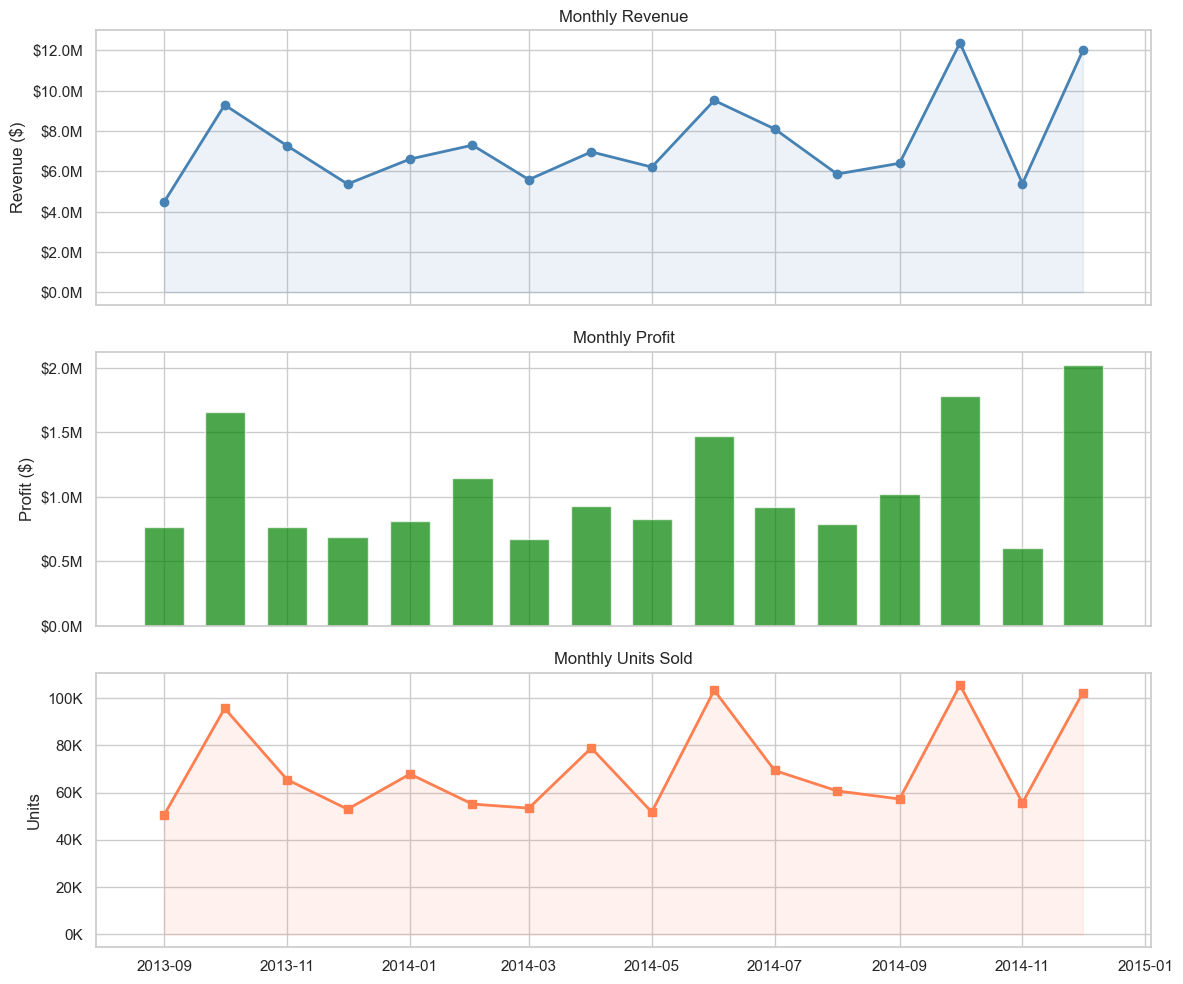

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Monthly Revenue
axes[0].plot(monthly.index, monthly['Sales'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Monthly Revenue')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].fill_between(monthly.index, monthly['Sales'], alpha=0.1, color='steelblue')

# Monthly Profit
colors = ['green' if v >= 0 else 'red' for v in monthly['Profit']]
axes[1].bar(monthly.index, monthly['Profit'], width=20, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Monthly Profit')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Monthly Units Sold
axes[2].plot(monthly.index, monthly['Units Sold'], marker='s', color='coral', linewidth=2)
axes[2].set_title('Monthly Units Sold')
axes[2].set_ylabel('Units')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[2].fill_between(monthly.index, monthly['Units Sold'], alpha=0.1, color='coral')

plt.tight_layout()
plt.show()

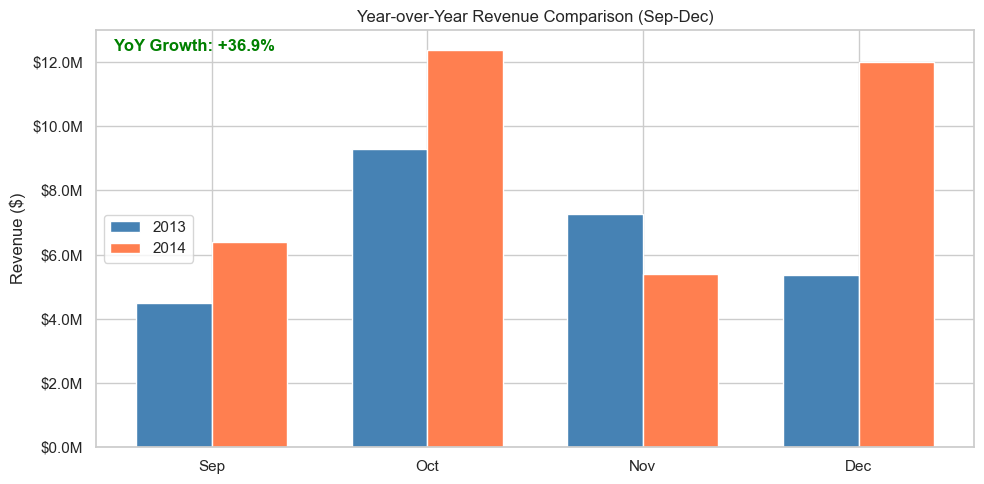

In [11]:
# Year-over-Year Comparison (2013 vs 2014) - only overlapping months (Sep-Dec)
df['Year'] = df['Date'].dt.year
df['MonthNum'] = df['Date'].dt.month

yearly = df.groupby(['Year', 'MonthNum'])['Sales'].sum().unstack(level=0)

# Only compare months present in both years
overlap_months = yearly.dropna()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(overlap_months))
width = 0.35

ax.bar([i - width/2 for i in x], overlap_months[2013], width, label='2013', color='steelblue')
ax.bar([i + width/2 for i in x], overlap_months[2014], width, label='2014', color='coral')

ax.set_xticks(x)
ax.set_xticklabels([month_names[m-1] for m in overlap_months.index])
ax.set_title('Year-over-Year Revenue Comparison (Sep-Dec)')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend()

# Calculate YoY growth
total_2013 = overlap_months[2013].sum()
total_2014 = overlap_months[2014].sum()
yoy_growth = ((total_2014 - total_2013) / total_2013) * 100
ax.annotate(f'YoY Growth: {yoy_growth:+.1f}%', xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=12, fontweight='bold', color='green' if yoy_growth > 0 else 'red')

plt.tight_layout()
plt.show()

---
## 5. Which Products Drive Results?
Revenue, profit, margin, and volume analysis by product.

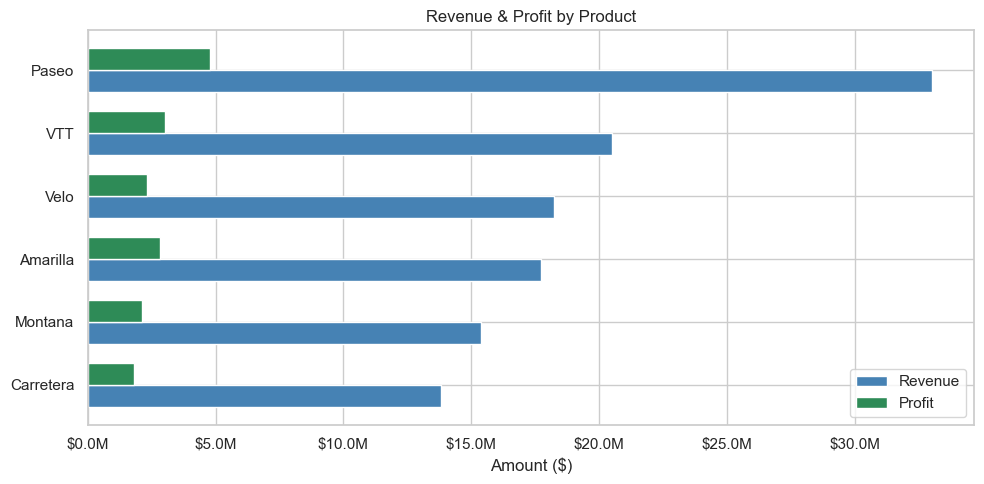

In [12]:
# Revenue & Profit by Product (grouped bar)
product_perf = df.groupby('Product').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(product_perf))
width = 0.35

ax.barh([i - width/2 for i in x], product_perf['Sales'], width, label='Revenue', color='steelblue')
ax.barh([i + width/2 for i in x], product_perf['Profit'], width, label='Profit', color='seagreen')

ax.set_yticks(x)
ax.set_yticklabels(product_perf.index)
ax.set_title('Revenue & Profit by Product')
ax.set_xlabel('Amount ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend()

plt.tight_layout()
plt.show()

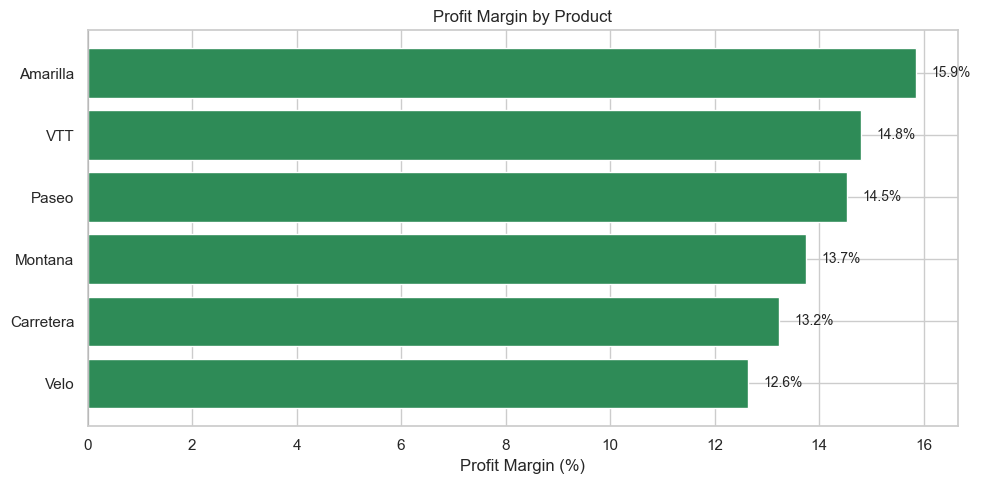

In [13]:
# Profit Margin by Product
product_margin = df.groupby('Product').agg({'Sales': 'sum', 'Profit': 'sum'})
product_margin['Margin %'] = (product_margin['Profit'] / product_margin['Sales']) * 100
product_margin = product_margin.sort_values('Margin %')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if m < 0 else 'seagreen' for m in product_margin['Margin %']]
ax.barh(product_margin.index, product_margin['Margin %'], color=colors)
ax.set_title('Profit Margin by Product')
ax.set_xlabel('Profit Margin (%)')
ax.axvline(x=0, color='black', linewidth=0.5)

for i, (idx, row) in enumerate(product_margin.iterrows()):
    ax.text(row['Margin %'] + 0.3, i, f'{row["Margin %"]:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

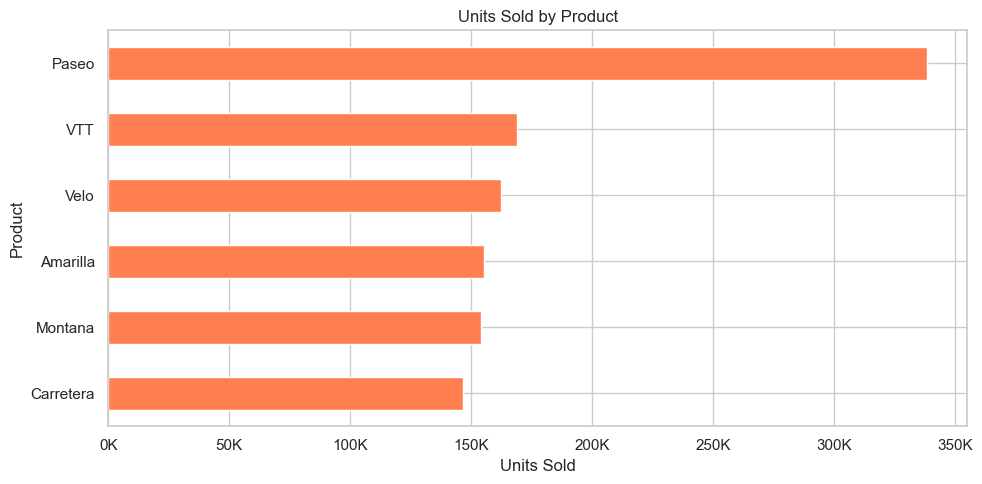

In [14]:
# Units Sold by Product
units_product = df.groupby('Product')['Units Sold'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
units_product.plot.barh(ax=ax, color='coral')
ax.set_title('Units Sold by Product')
ax.set_xlabel('Units Sold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

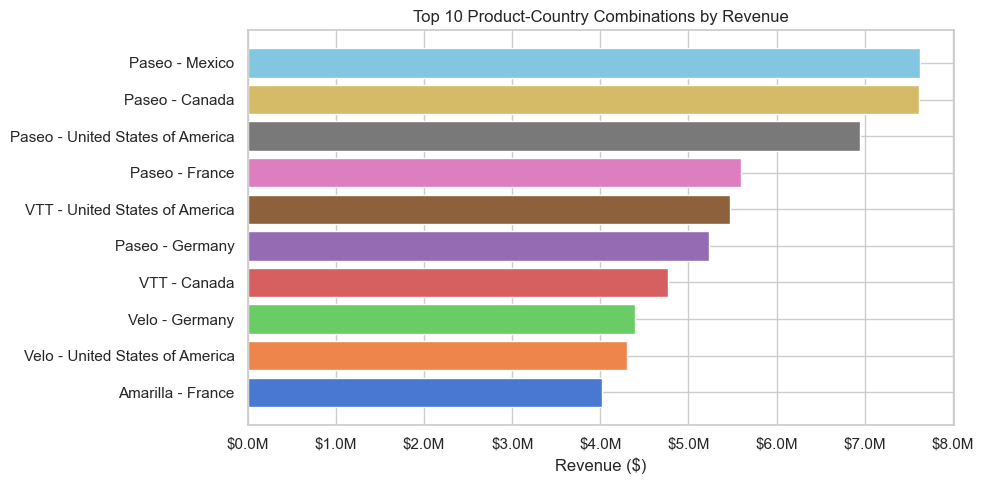

In [15]:
# Top Product-Country Combinations by Revenue
top_combos = (df.groupby(['Product', 'Country'])['Sales'].sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())
top_combos['Label'] = top_combos['Product'] + ' - ' + top_combos['Country']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_combos['Label'][::-1], top_combos['Sales'][::-1], color=sns.color_palette('muted', 10))
ax.set_title('Top 10 Product-Country Combinations by Revenue')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

---
## 6. Are Sales Profitable?
Profitability analysis by segment, country, discount band, and loss-making transactions.

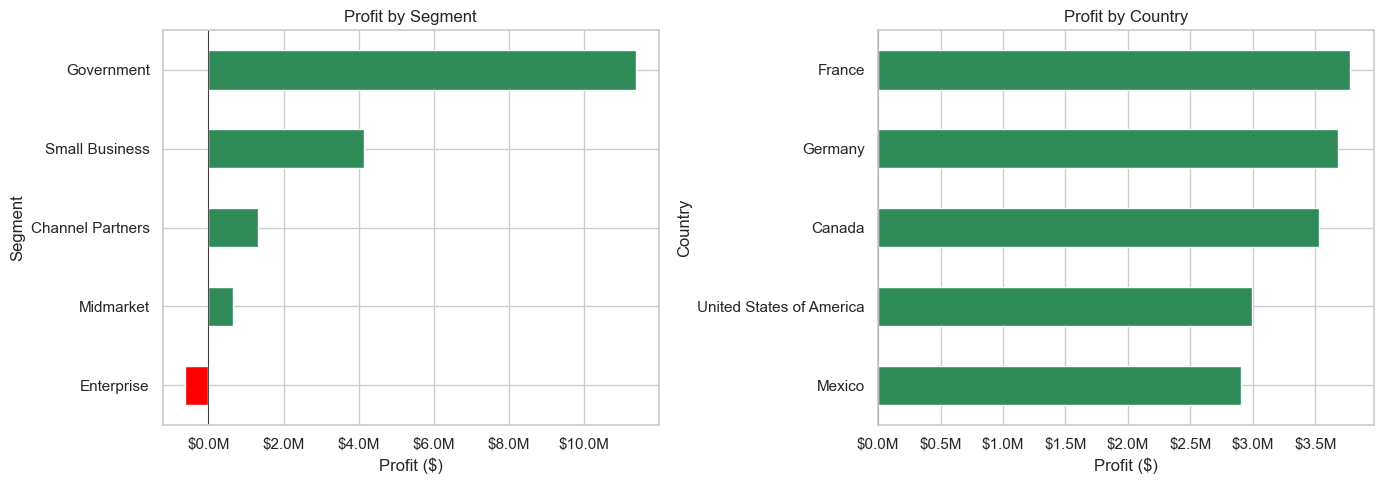

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Segment
profit_segment = df.groupby('Segment')['Profit'].sum().sort_values()
colors_seg = ['red' if v < 0 else 'seagreen' for v in profit_segment]
profit_segment.plot.barh(ax=axes[0], color=colors_seg)
axes[0].set_title('Profit by Segment')
axes[0].set_xlabel('Profit ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Profit by Country
profit_country = df.groupby('Country')['Profit'].sum().sort_values()
colors_co = ['red' if v < 0 else 'seagreen' for v in profit_country]
profit_country.plot.barh(ax=axes[1], color=colors_co)
axes[1].set_title('Profit by Country')
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

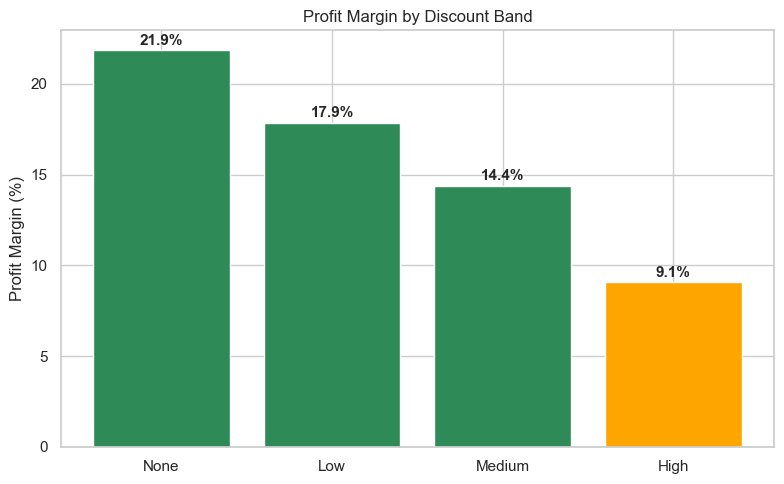

In [17]:
# Profit Margin by Discount Band
discount_analysis = df.groupby('Discount Band').agg({'Sales': 'sum', 'Profit': 'sum'})
discount_analysis['Margin %'] = (discount_analysis['Profit'] / discount_analysis['Sales']) * 100
discount_order = ['None', 'Low', 'Medium', 'High']
discount_analysis = discount_analysis.reindex(discount_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors_disc = ['seagreen' if m > 10 else 'orange' if m > 0 else 'red' for m in discount_analysis['Margin %']]
bars = ax.bar(discount_analysis.index, discount_analysis['Margin %'], color=colors_disc)
ax.set_title('Profit Margin by Discount Band')
ax.set_ylabel('Profit Margin (%)')
ax.axhline(y=0, color='black', linewidth=0.5)

for bar, margin in zip(bars, discount_analysis['Margin %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{margin:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# Loss-Making Transactions Analysis
losses = df[df['Profit'] < 0]
total_transactions = len(df)
loss_count = len(losses)
loss_pct = (loss_count / total_transactions) * 100
total_loss = losses['Profit'].sum()

print(f'Loss-making transactions: {loss_count} out of {total_transactions} ({loss_pct:.1f}%)')
print(f'Total losses: ${total_loss:,.0f}')
print()

print('Losses by Product:')
print(losses.groupby('Product')['Profit'].agg(['count', 'sum']).sort_values('sum').to_string())
print()

print('Losses by Segment:')
print(losses.groupby('Segment')['Profit'].agg(['count', 'sum']).sort_values('sum').to_string())
print()

print('Losses by Discount Band:')
print(losses.groupby('Discount Band')['Profit'].agg(['count', 'sum']).sort_values('sum').to_string())

Loss-making transactions: 58 out of 700 (8.3%)
Total losses: $-777,321

Losses by Product:
           count        sum
Product                    
Carretera     12 -231110.00
Velo          13 -125456.25
Amarilla       9 -121940.00
VTT            8 -121740.00
Paseo         11 -120548.75
Montana        5  -56526.25

Losses by Segment:
            count        sum
Segment                     
Enterprise     58 -777321.25

Losses by Discount Band:
               count        sum
Discount Band                  
High              33 -622368.75
Medium            25 -154952.50


---
## 7. Key Findings & Recommendations

In [19]:
# Generate key findings dynamically from the data
top_country = df.groupby('Country')['Sales'].sum().idxmax()
top_country_rev = df.groupby('Country')['Sales'].sum().max()

top_product = df.groupby('Product')['Sales'].sum().idxmax()
top_product_rev = df.groupby('Product')['Sales'].sum().max()

top_segment = df.groupby('Segment')['Profit'].sum().idxmax()
top_segment_profit = df.groupby('Segment')['Profit'].sum().max()

worst_segment = df.groupby('Segment')['Profit'].sum().idxmin()
worst_segment_profit = df.groupby('Segment')['Profit'].sum().min()

best_margin_product = product_margin['Margin %'].idxmax()
best_margin_value = product_margin['Margin %'].max()

print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print()
print(f'1. TOP MARKET: {top_country} leads revenue at ${top_country_rev:,.0f}')
print(f'2. TOP PRODUCT: {top_product} is the revenue leader at ${top_product_rev:,.0f}')
print(f'3. MOST PROFITABLE SEGMENT: {top_segment} generates ${top_segment_profit:,.0f} profit')
print(f'4. LOSS-MAKING: {loss_count} transactions ({loss_pct:.1f}%) are unprofitable, totaling ${abs(total_loss):,.0f} in losses')
print(f'5. DISCOUNTS: Higher discount bands correlate with lower profit margins')
print(f'6. BEST MARGIN: {best_margin_product} has the highest margin at {best_margin_value:.1f}%')
print(f'7. YoY GROWTH: Revenue grew {yoy_growth:+.1f}% comparing Sep-Dec 2013 vs 2014')
print()
print('=' * 60)
print('RECOMMENDATIONS')
print('=' * 60)
print()
print(f'1. EXPAND in {top_country}: Strongest market with highest revenue potential')
print(f'2. REVIEW {worst_segment} segment: Generating only ${worst_segment_profit:,.0f} — investigate pricing and costs')
print(f'3. OPTIMIZE DISCOUNTS: High-discount transactions erode margins — cap or restructure discount tiers')
print(f'4. SCALE {best_margin_product}: Highest margin product — increase marketing investment')
print(f'5. INVESTIGATE LOSSES: Address the {loss_count} loss-making transactions to recover ${abs(total_loss):,.0f}')

KEY FINDINGS

1. TOP MARKET: United States of America leads revenue at $25,029,830
2. TOP PRODUCT: Paseo is the revenue leader at $33,011,144
3. MOST PROFITABLE SEGMENT: Government generates $11,388,173 profit
4. LOSS-MAKING: 58 transactions (8.3%) are unprofitable, totaling $777,321 in losses
5. DISCOUNTS: Higher discount bands correlate with lower profit margins
6. BEST MARGIN: Amarilla has the highest margin at 15.9%
7. YoY GROWTH: Revenue grew +36.9% comparing Sep-Dec 2013 vs 2014

RECOMMENDATIONS

1. EXPAND in United States of America: Strongest market with highest revenue potential
2. REVIEW Enterprise segment: Generating only $-614,546 — investigate pricing and costs
3. OPTIMIZE DISCOUNTS: High-discount transactions erode margins — cap or restructure discount tiers
4. SCALE Amarilla: Highest margin product — increase marketing investment
5. INVESTIGATE LOSSES: Address the 58 loss-making transactions to recover $777,321


In [20]:
# Clean up helper columns
df = df.drop(['Month', 'Year', 'MonthNum'], axis=1, errors='ignore')